In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')


# Some Useful Imports

In [3]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # advanced visualization

import missingno as msno

from scipy.stats import loguniform,uniform  # log-uniform distribution for random search

# Machine Learning Models & Utilities
from sklearn.dummy import DummyRegressor  # baseline regressor
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV, SGDRegressor  # linear models
from sklearn.ensemble import RandomForestClassifier,VotingClassifier  # Random Forest classifier
from lightgbm import LGBMClassifier  # LightGBM classifier
from xgboost import XGBClassifier  # XGBoost classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Feature Selection
from sklearn.feature_selection import RFE , SelectKBest, chi2   # recursive feature elimination

# Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, accuracy_score, classification_report, r2_score,confusion_matrix  # evaluation metrics

# Model Selection & Validation
from sklearn.model_selection import cross_validate, cross_val_score, train_test_split, ShuffleSplit, validation_curve, GridSearchCV, RandomizedSearchCV , cross_val_score # model validation

# Dimensionality Reduction
from sklearn.decomposition import PCA  # principal component analysis

# Preprocessing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder  # preprocessing utilities
from sklearn.impute import SimpleImputer  # handling missing values

# Pipeline & Transformation
from sklearn.pipeline import Pipeline  # building ML pipelines
from sklearn.compose import ColumnTransformer  # applying transformers to subsets of features

# Miscellaneous
import joblib  # saving/loading models

from sklearn.preprocessing import StandardScaler, OneHotEncoder,MinMaxScaler

from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Loding Dataset

In [4]:
df_train = pd.read_csv('/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv')
df_test = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv")
df_train.head()
# df_test.head()

,last contact date,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target
0,2009-04-17,26,blue-collar,married,secondary,no,647,yes,no,cellular,357,2,331,1,other,no
1,2009-10-11,52,technician,married,secondary,no,553,yes,no,telephone,160,1,-1,0,NaN,no
2,2010-11-20,44,blue-collar,married,secondary,no,1397,no,no,cellular,326,1,-1,0,NaN,no
3,2009-09-01,33,admin.,married,secondary,no,394,yes,no,telephone,104,3,-1,0,NaN,no
4,2008-01-29,31,entrepreneur,single,tertiary,no,137,no,no,cellular,445,2,-1,0,NaN,no


## Feature Descriptions

This dataset is used in the "Predict the Success of Bank Telemarketing" competition. It contains various features that provide insights into customer demographics, campaign details, and previous interactions. Below is a comprehensive description of each feature:

### **1. age**
- Represents the age of the client in years. Age is often a critical factor in marketing campaigns, as it may indicate a client’s financial stability, preferences, or likelihood to invest in a term deposit.

---

### **2. job**
- Denotes the type of job the client holds. Examples include:
  - 'admin.': Administrative jobs
  - 'blue-collar': Manual or industrial jobs
  - 'entrepreneur': Business owners or entrepreneurs
  - 'management', 'technician', etc.
- Understanding a client's job type can provide insights into their income level and potential interest in financial products.

---

### **3. marital**
- Indicates the marital status of the client. Values include:
  - 'married': Married clients
  - 'single': Clients who are not married
  - 'divorced': Divorced clients
- Marital status can influence financial priorities and decision-making processes.

---

### **4. education**
- Describes the highest level of education attained by the client. Categories include:
  - 'primary': Basic education
  - 'secondary': High school education
  - 'tertiary': Higher education (e.g., college, university)
  - 'unknown': Missing or undefined information
- Education level often correlates with income and financial literacy, which may impact the likelihood of subscribing to a term deposit.

---

### **5. default**
- Indicates whether the client has a credit in default ('yes', 'no'). Clients with a credit in default may have financial constraints, reducing their ability to invest in term deposits.

---

### **6. balance**
- Represents the average yearly balance (in euros) of the client's bank account. This feature reflects the financial standing of the client and can indicate their capacity to make new investments.

---

### **7. housing**
- Indicates if the client has a housing loan ('yes', 'no'). Housing loans might suggest financial commitments that could affect the client's ability to invest in term deposits.

---

### **8. loan**
- Denotes whether the client has a personal loan ('yes', 'no'). Clients with personal loans may have limited disposable income for additional investments.

---

### **9. contact**
- Specifies the type of communication used to contact the client:
  - 'cellular': Contacted via mobile phone
  - 'telephone': Contacted via landline
- The communication method can influence the likelihood of a successful interaction.

---

### **10. day**
- The day of the month when the client was last contacted during the campaign (numeric value). This feature, combined with the `month` feature, provides insights into seasonal trends and campaign effectiveness.

---

### **11. month**
- The last contact month of the year. Examples include 'jan', 'feb', 'mar', etc. Certain months may have higher success rates due to seasonal or financial cycles.

---

### **12. duration**
- The duration (in seconds) of the last contact with the client. **Important Note**: Duration is strongly correlated with the target outcome (`y`), as longer interactions often indicate a positive outcome. Careful consideration is required when including this feature in the model to avoid data leakage.

---

### **13. campaign**
- The number of contacts performed during this campaign for the client (includes the last contact). Higher contact counts could indicate persistent attempts to convert the client, but may also result in client fatigue.

---

### **14. pdays**
- The number of days that have passed since the client was last contacted from a previous campaign. A value of 999 indicates that the client was not previously contacted. This feature helps understand whether previous contact history affects current campaign success.

---

### **15. previous**
- The number of contacts performed before this campaign for the client. This feature indicates prior engagement levels, which may influence the client’s willingness to respond positively.

---

### **16. poutcome**
- The outcome of the previous marketing campaign for this client. Categories include:
  - 'success': The client subscribed to a term deposit during the previous campaign.
  - 'failure': The client did not subscribe during the previous campaign.
  - 'other': Other outcomes (e.g., client refusal, disconnected contact).
  - 'unknown': No previous campaign or unknown outcome.
- The previous outcome may serve as a strong predictor of current campaign success.

---

### **17. y (target)**
- The target variable indicating whether the client subscribed to a term deposit:
  - 'yes': The client subscribed.
  - 'no': The client did not subscribe.
- This binary outcome is the variable to be predicted using the provided features.

---

### Key Insights
- This dataset combines demographic, financial, and campaign-specific attributes. Careful preprocessing, feature engineering, and interpretation are required to maximize predictive performance. Features such as `duration`, `pdays`, and `poutcome` are particularly influential in understanding client behavior and campaign success.


# Data Visualization

## Bar plot of missing values

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,39211.0,42.120247,12.709352,18.0,33.0,40.0,50.0,95.0
balance,39211.0,5441.781719,16365.292065,-8019.0,98.0,549.0,2030.0,102127.0
duration,39211.0,439.062789,769.096291,0.0,109.0,197.0,380.0,4918.0
campaign,39211.0,5.108770,9.890153,1.0,1.0,2.0,4.0,63.0
pdays,39211.0,72.256051,160.942593,-1.0,-1.0,-1.0,-1.0,871.0
previous,39211.0,11.826171,44.140259,0.0,0.0,0.0,0.0,275.0


###  1. Target Class Distribution


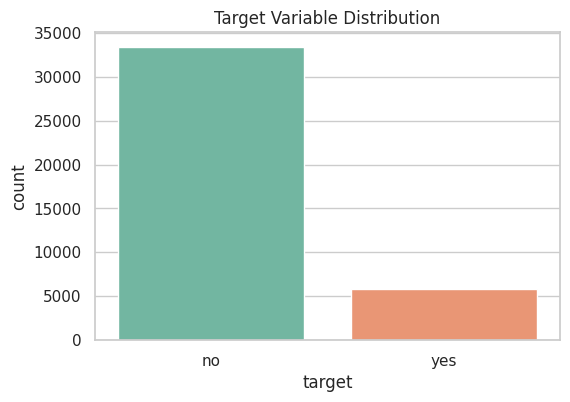

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_train, palette='Set2')
plt.title('Target Variable Distribution')
plt.show()

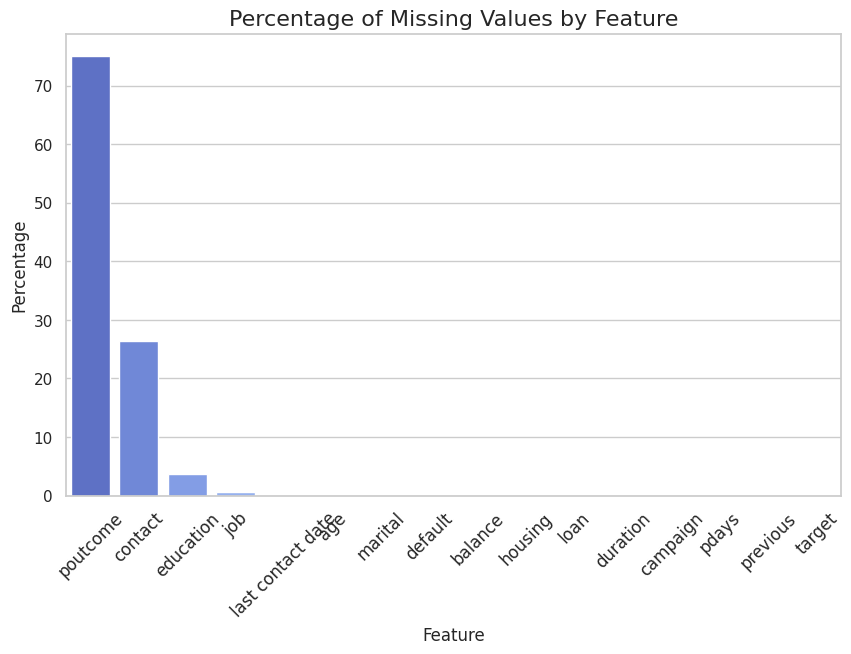

In [7]:

missing_values = df_train.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(df_train)) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette="coolwarm")
plt.xticks(rotation=45, fontsize=12)
plt.title("Percentage of Missing Values by Feature", fontsize=16)
plt.ylabel("Percentage")
plt.xlabel("Feature")
plt.show()

### 2. Outlier Detection using Boxplots ###

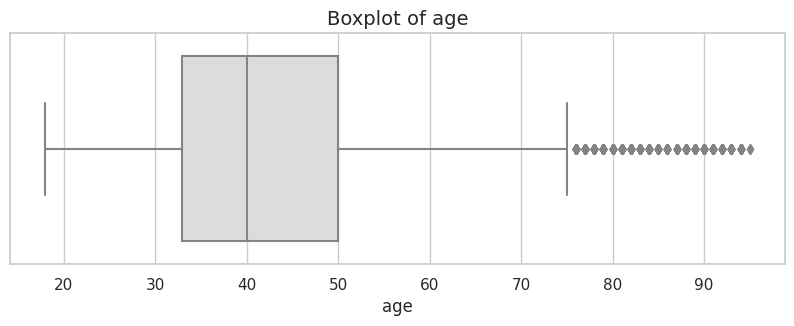

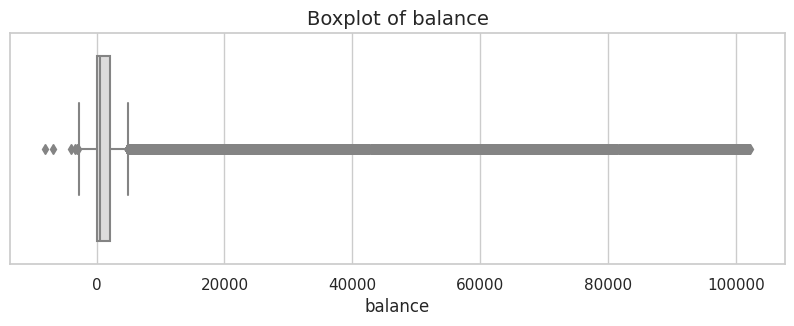

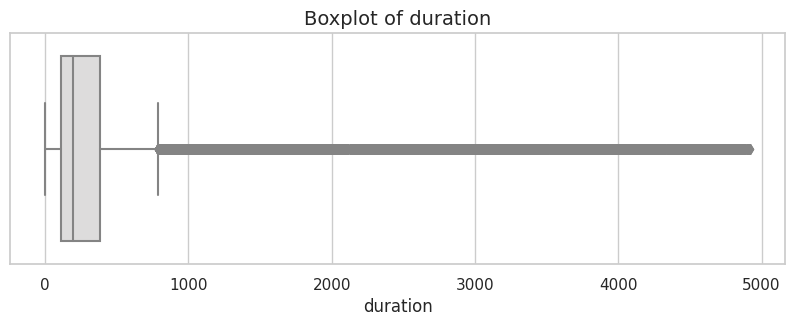

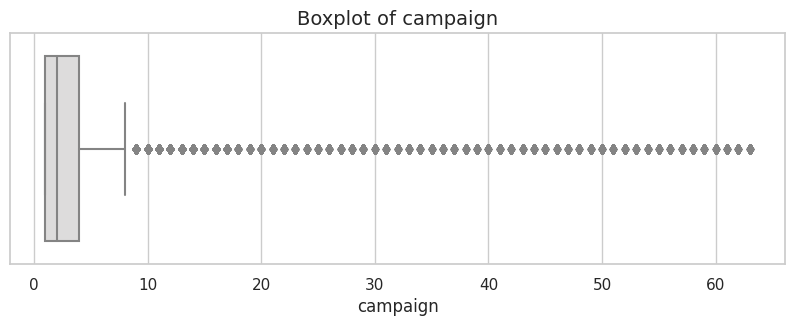

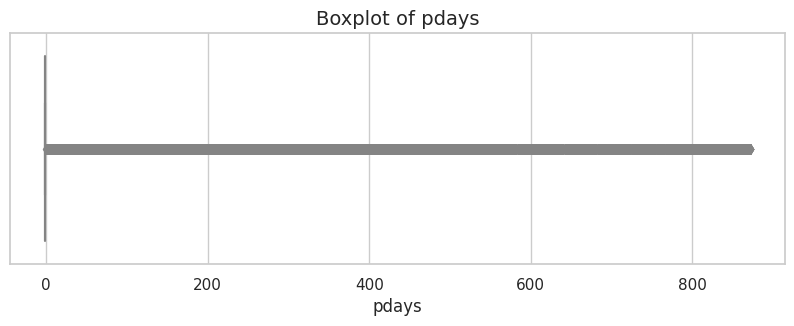

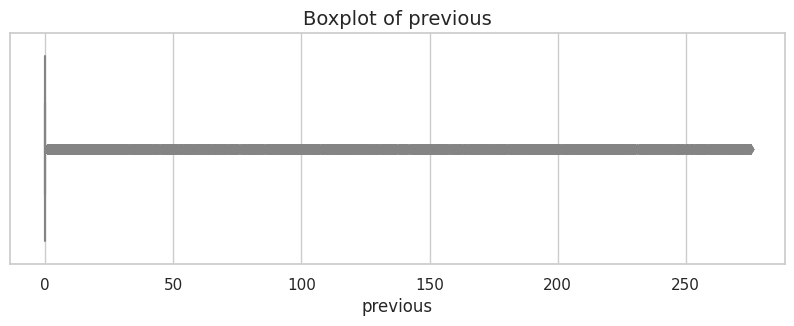

In [8]:
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
for col in numerical_features:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df_train[col], palette="coolwarm")
    plt.title(f"Boxplot of {col}", fontsize=14)
    plt.show()

### 3. Distribution of Numerical Features ###

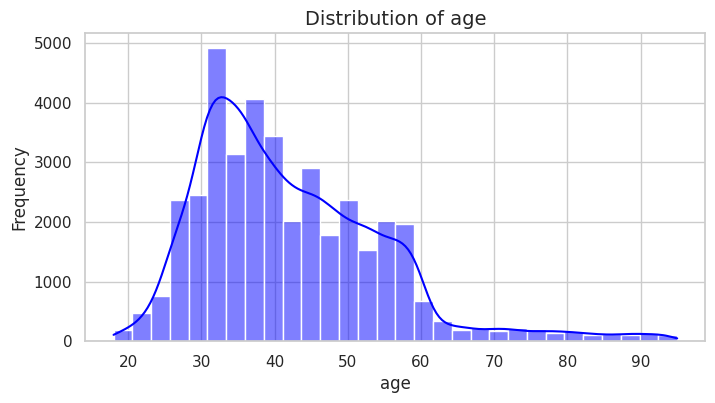

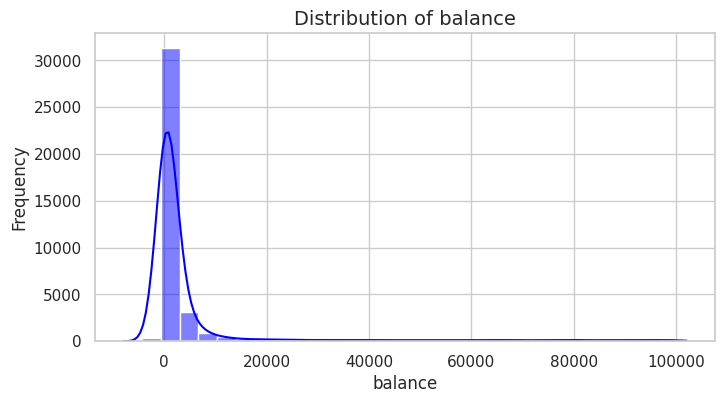

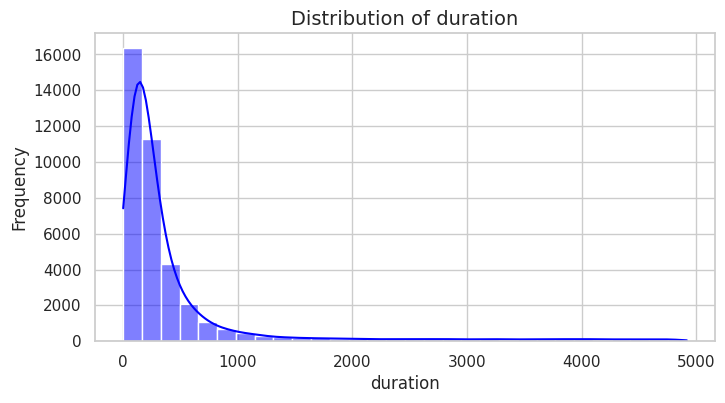

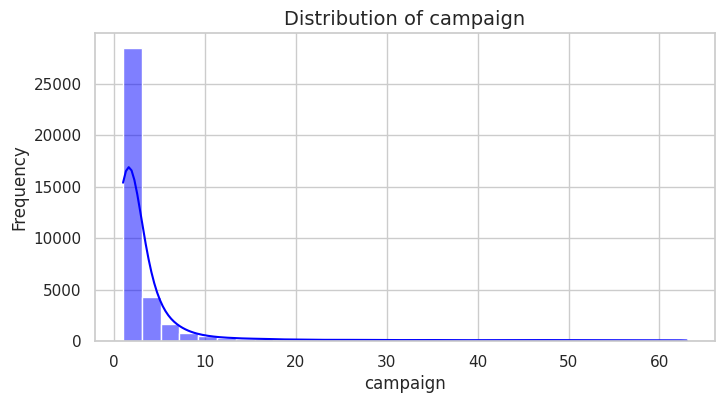

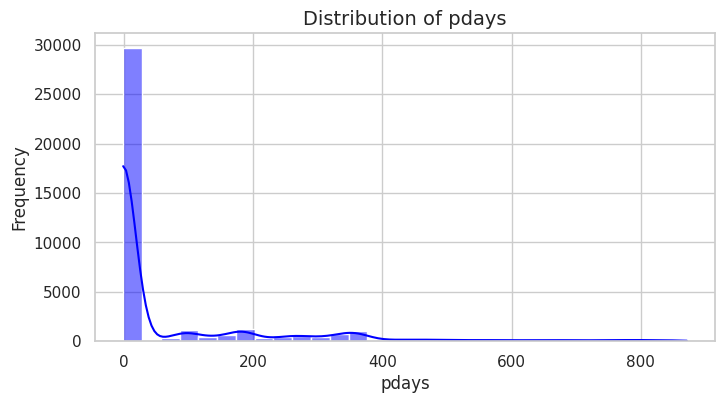

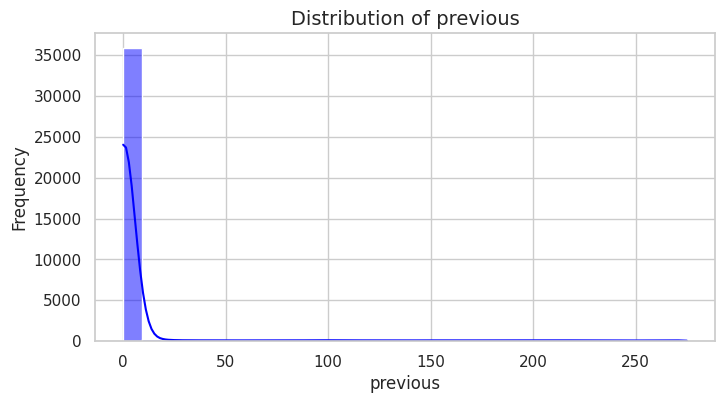

In [9]:

for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[col], kde=True, bins=30, color="blue")
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 4. Correlation Heatmap ###

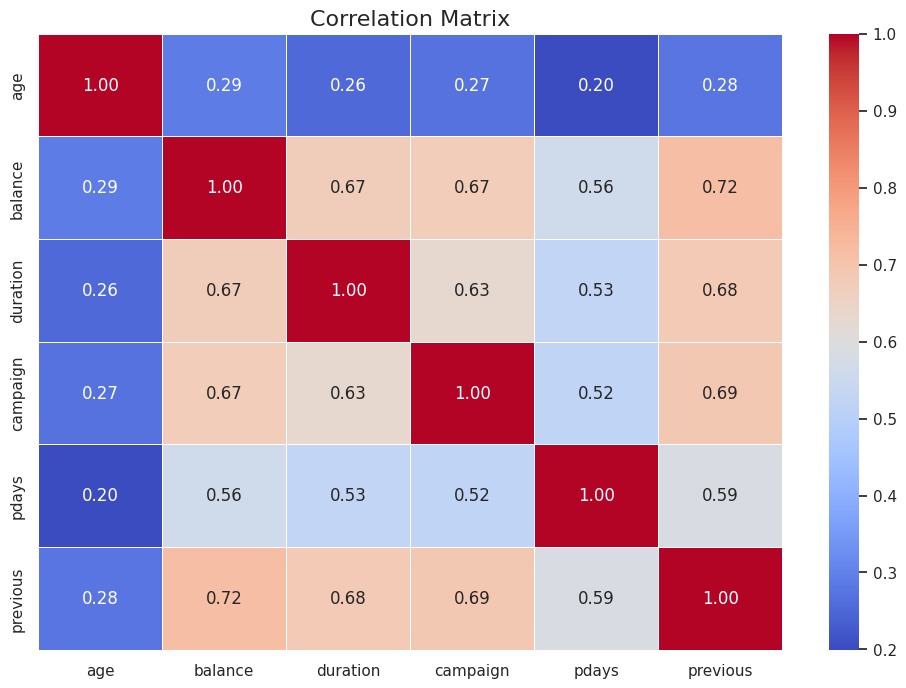

In [10]:

plt.figure(figsize=(12, 8))
correlation_matrix = df_train[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

### 5. Categorical Feature Visualizations ###

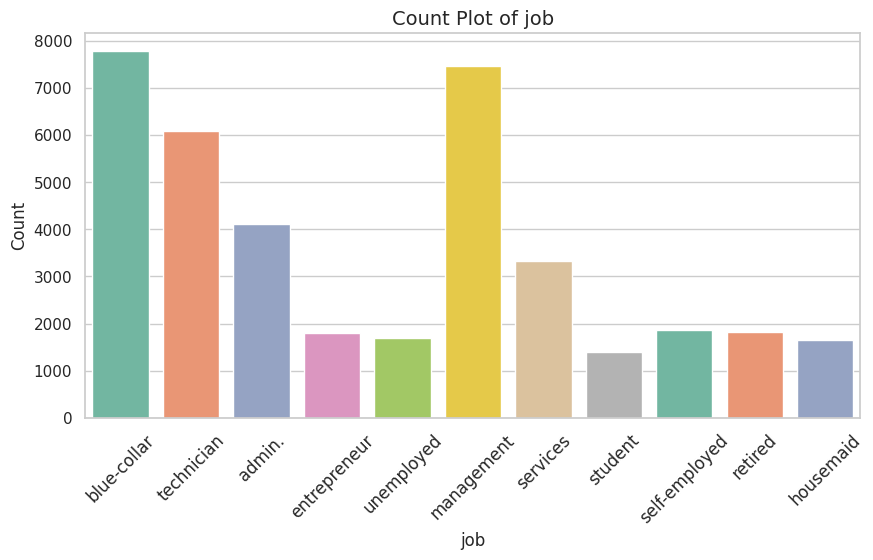

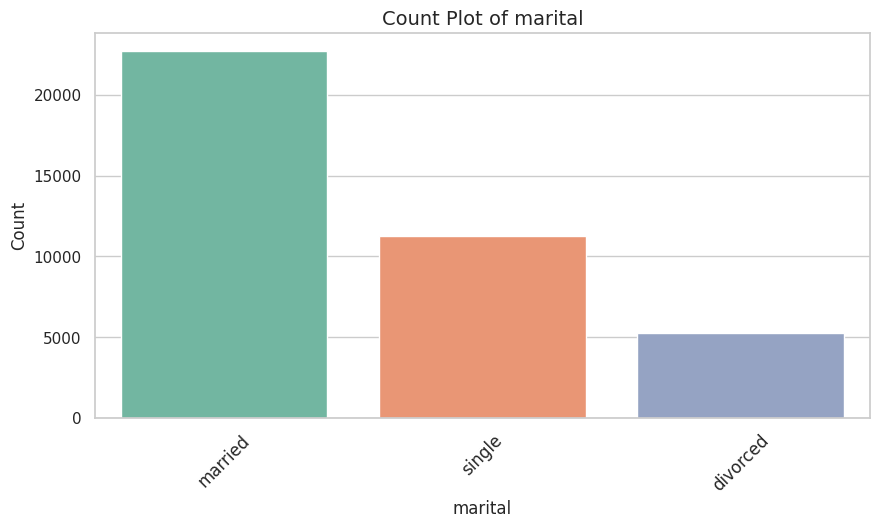

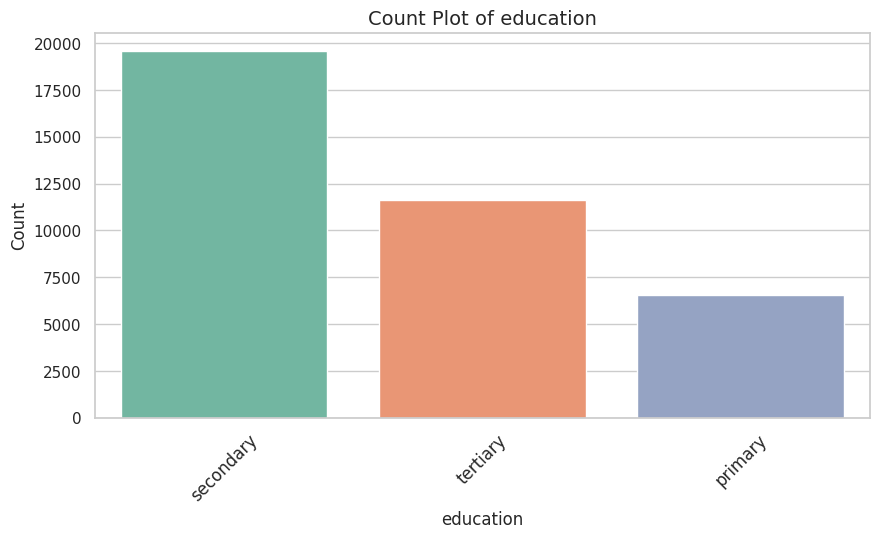

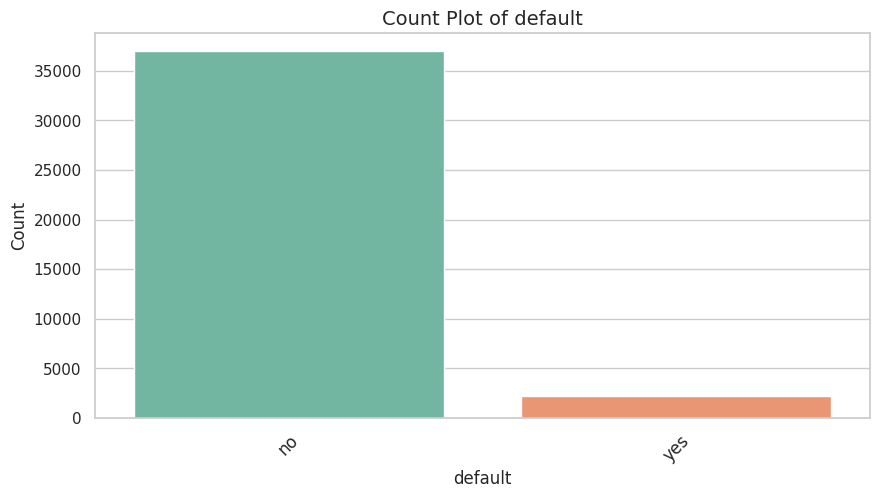

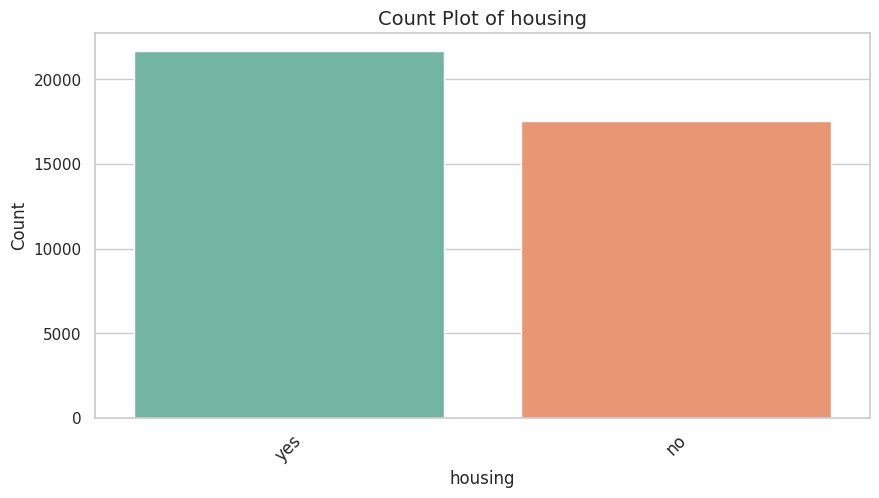

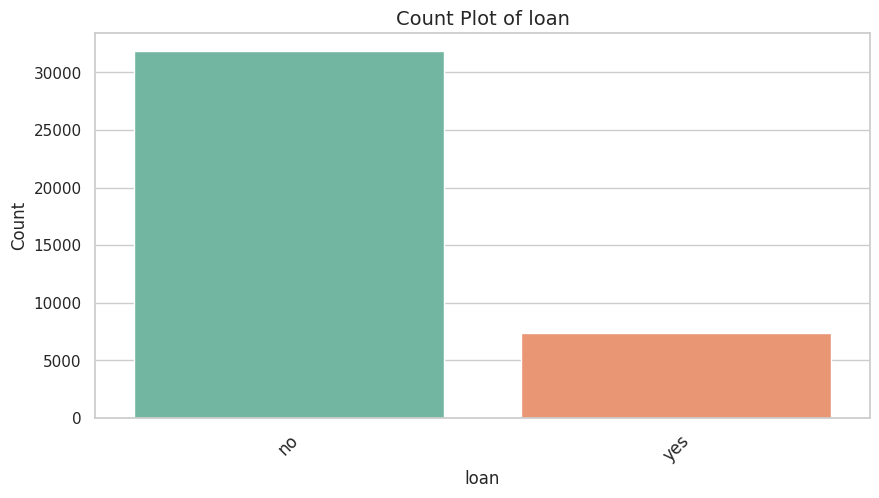

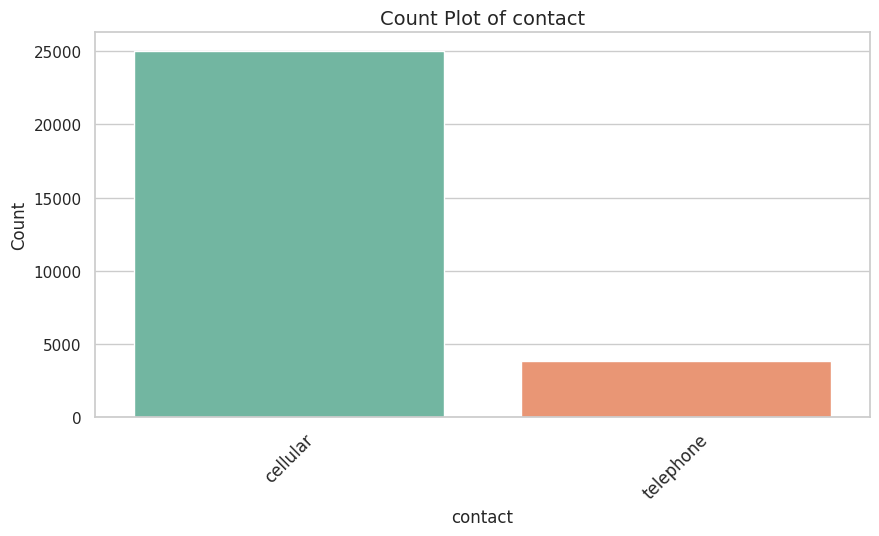

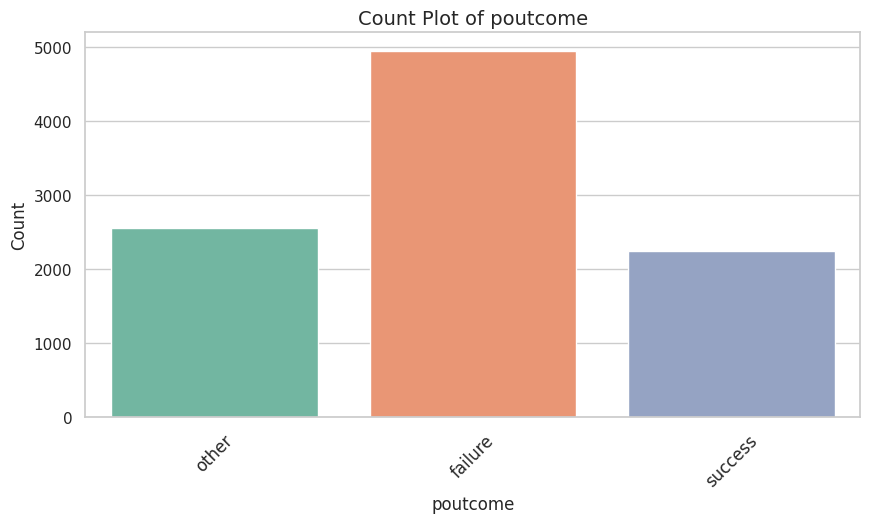

In [11]:

categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df_train[col], palette="Set2")
    plt.xticks(rotation=45, fontsize=12)
    plt.title(f"Count Plot of {col}", fontsize=14)
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.show()

### 6. Target vs. Feature Analysis ###

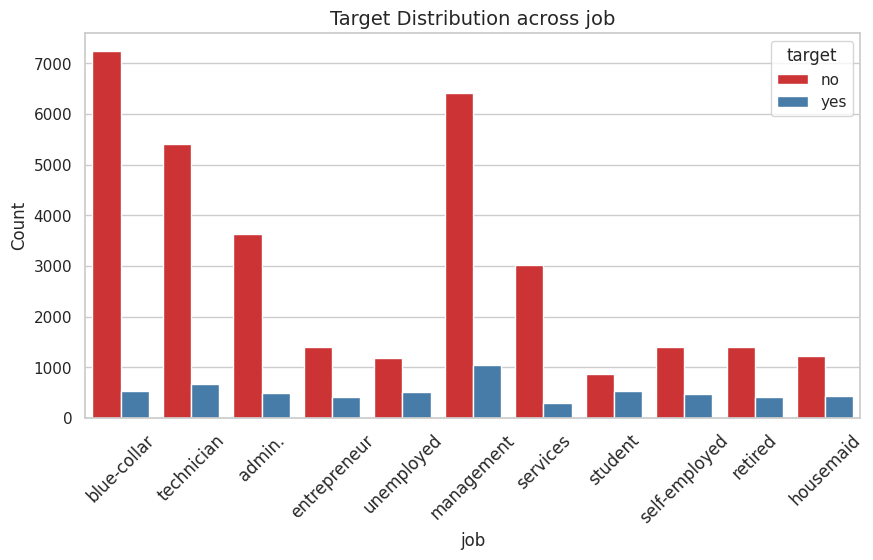

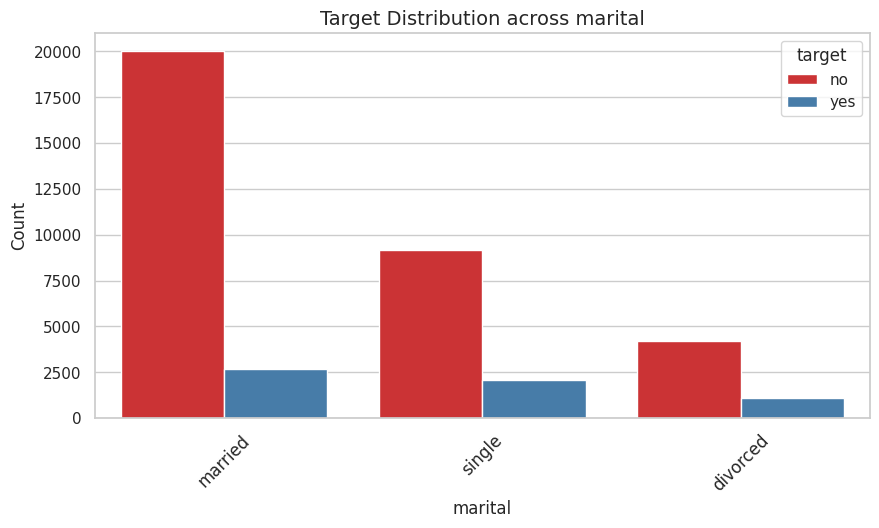

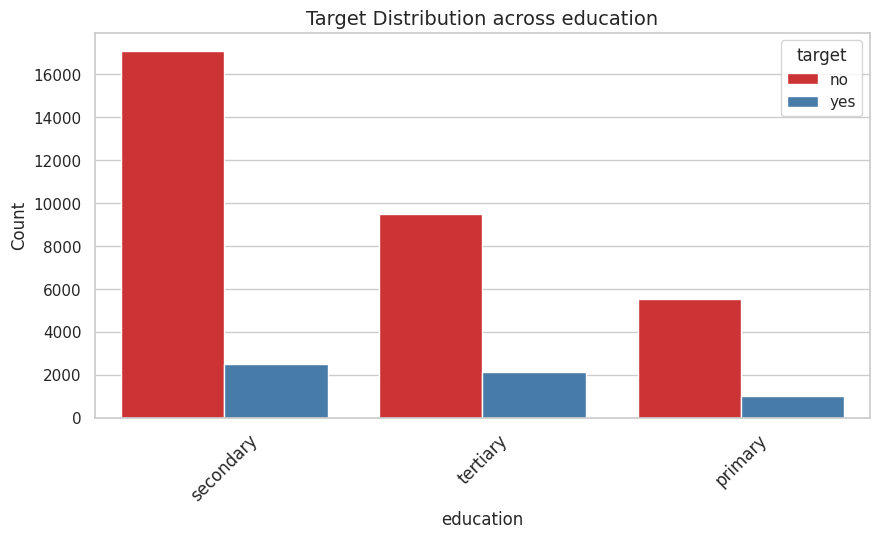

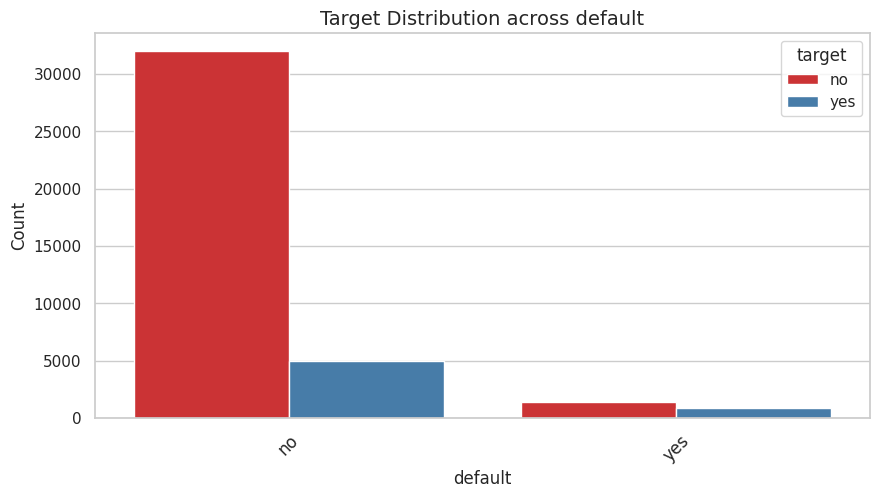

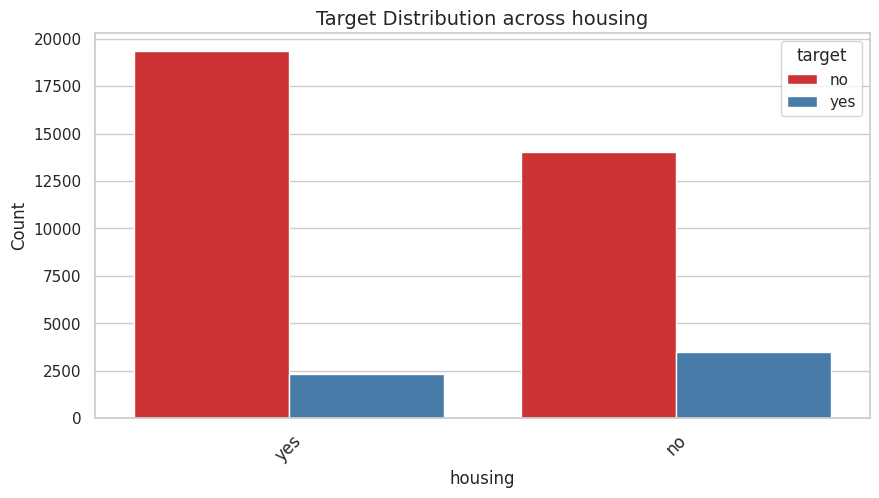

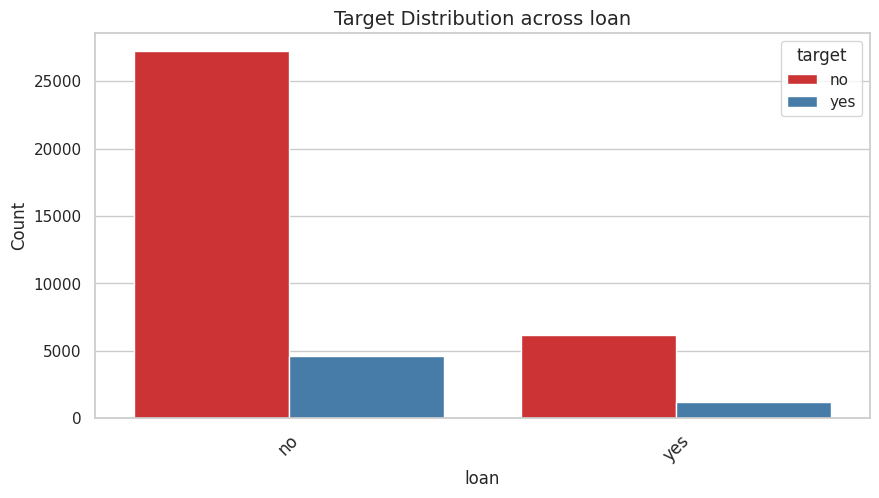

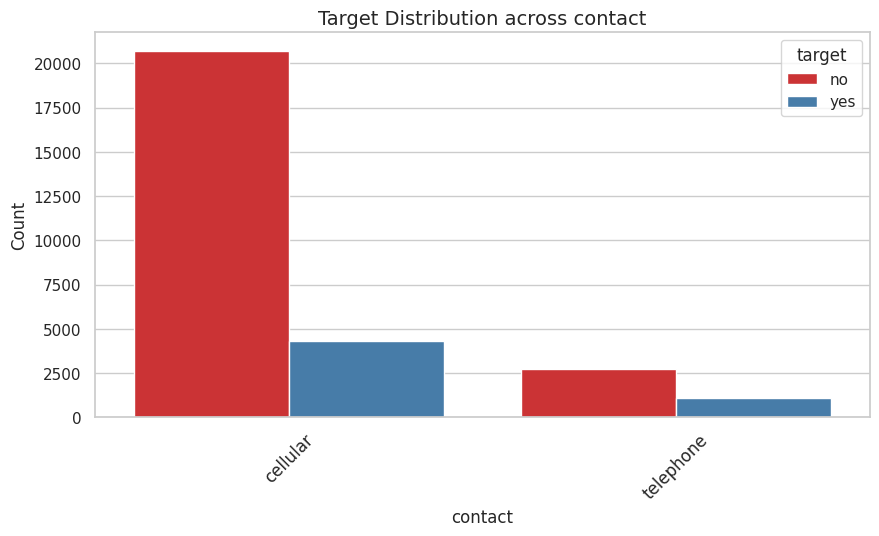

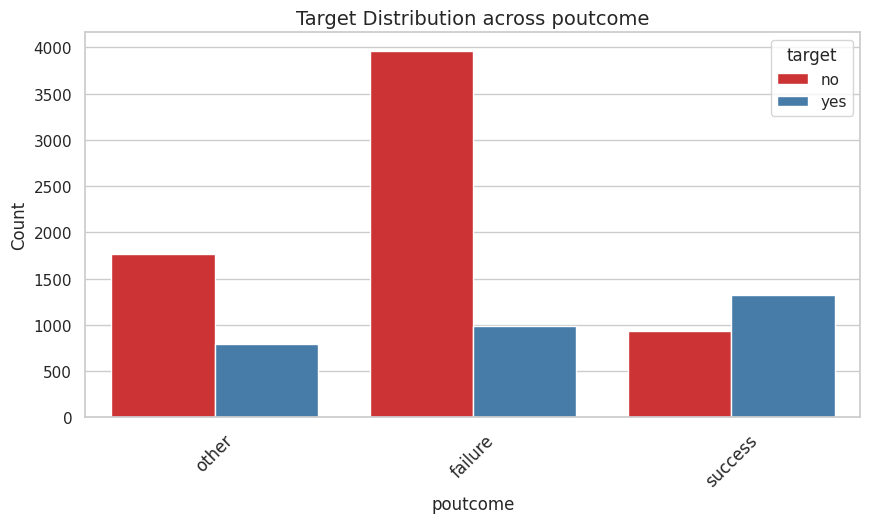

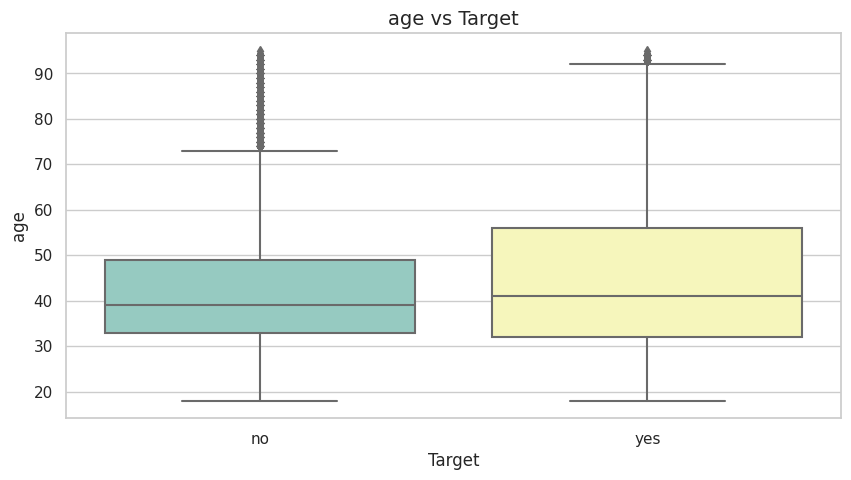

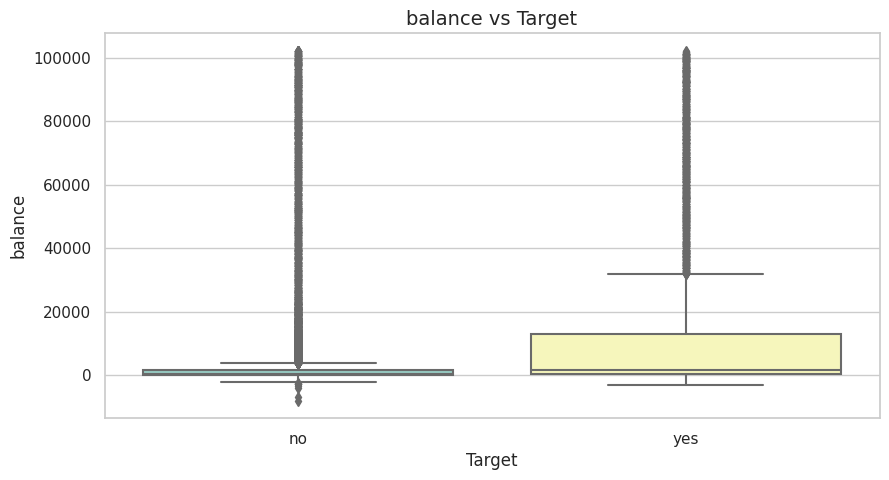

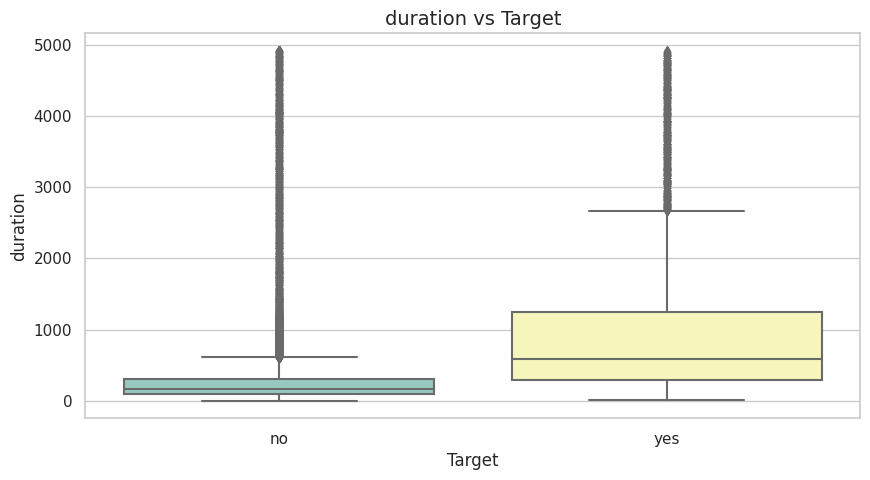

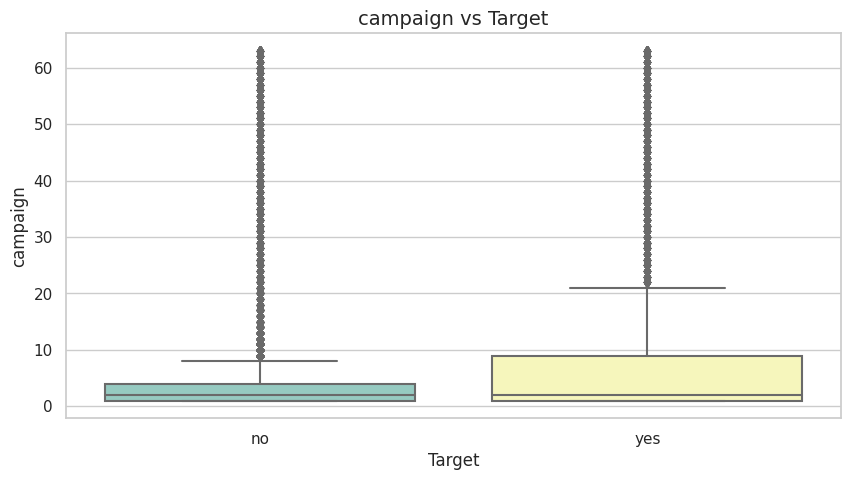

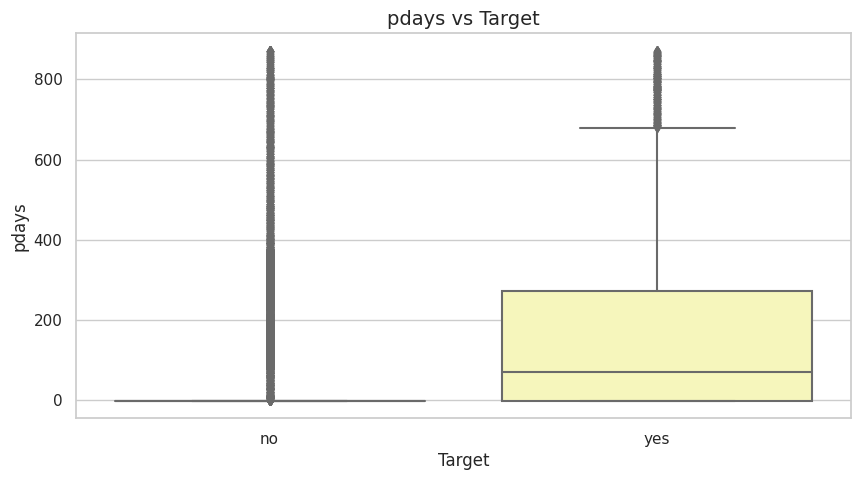

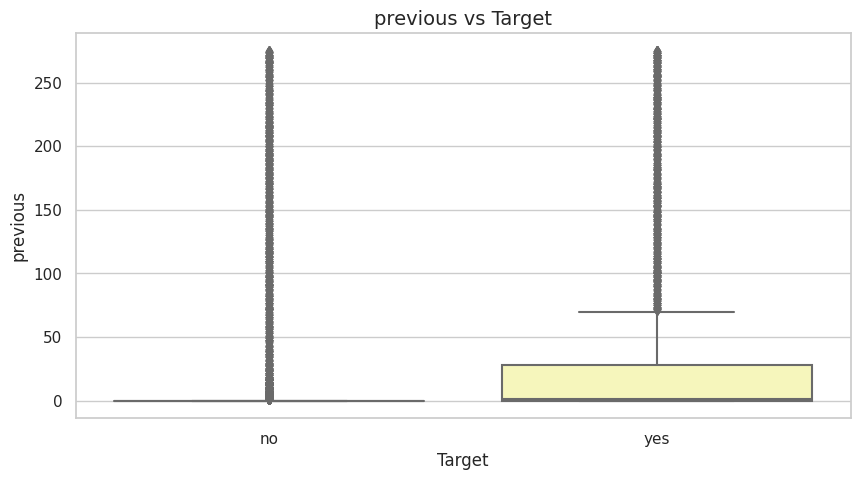

In [12]:
for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df_train[col], hue=df_train['target'], palette="Set1")
    plt.xticks(rotation=45, fontsize=12)
    plt.title(f"Target Distribution across {col}", fontsize=14)
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.show()

for col in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df_train['target'], y=df_train[col], palette="Set3")
    plt.title(f"{col} vs Target", fontsize=14)
    plt.ylabel(col)
    plt.xlabel("Target")
    plt.show()

### Key Insights from Visualizations

1. **Target Variable Imbalance**  
   - The target variable (`target`) exhibits imbalanced classes. This imbalance may lead to biased predictions favoring the majority class. Addressing this issue through techniques like **SMOTE (Synthetic Minority Oversampling Technique)**, **undersampling**, or applying **class-weight adjustments** in models is crucial for achieving better prediction performance.

2. **Outliers**  
   - Features such as **`balance`**, **`duration`**, and **`campaign`** contain significant outliers, as evident from the boxplots. These outliers can negatively impact model training by introducing noise. **Outlier removal** or **transformation techniques** (e.g., capping or using logarithmic scaling) can help reduce the model's sensitivity to extreme values.

3. **Missing Values**  
   - Features such as **`job`**, **`education`**, **`contact`**, and **`poutcome`** have missing values that need to be addressed. Using **imputation strategies** like filling with the mode for categorical features or predictive imputation is necessary to ensure data completeness.

4. **Skewed Distributions**  
   - Features like **`balance`** and **`duration`** have heavily skewed distributions, as seen in the histograms. Applying **log transformations** or **scaling methods** can normalize these distributions, improving model performance.

5. **Feature Correlation**  
   - The correlation heatmap indicates that some features, such as **`pdays`** and **`previous`**, are highly correlated, potentially leading to multicollinearity. Applying **dimensionality reduction** techniques (e.g., PCA) or removing redundant features can address this issue.

6. **Categorical Features**  
   - Categorical features like **`job`**, **`marital`**, **`education`**, and **`contact`** show considerable variability. Proper **encoding techniques** such as **one-hot encoding** or **target encoding** are required to make these features suitable for machine learning models.


# Preprocessing

In [13]:
df_train.shape

(39211, 16)

In [14]:
df_train.isnull().sum()

last contact date        0
age                      0
job                    229
marital                  0
education             1467
default                  0
balance                  0
housing                  0
loan                     0
contact              10336
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome             29451
target                   0
dtype: int64

In [15]:
print(f"Count of NaN values in 'train_csv': {df_train.isna().sum().sum()} ")
print(f"Count of NaN values in 'test_csv': {df_test.isna().sum().sum()} ")

Count of NaN values in 'train_csv': 41483 
Count of NaN values in 'test_csv': 10641 


# Creating separate columns for year, month, and day

In [16]:
date_format = '%Y-%m-%d'
df_train['last contact date'] = pd.to_datetime(df_train['last contact date'], format=date_format, errors='coerce')

df_train['year'] = df_train['last contact date'].dt.year
df_train['month'] = df_train['last contact date'].dt.month
df_train['day_of_week'] = df_train['last contact date'].dt.dayofweek  # Adding day of the week (0=Monday, 6=Sunday)

df_train = df_train.drop(columns=['last contact date'])


In [17]:
df_test['last contact date'] = pd.to_datetime(df_test['last contact date'], format=date_format, errors='coerce')
df_test['year'] = df_test['last contact date'].dt.year
df_test['month'] = df_test['last contact date'].dt.month
df_test['day_of_week'] = df_test['last contact date'].dt.dayofweek  # Adding day of the week (0=Monday, 6=Sunday)

df_test = df_test.drop(columns=['last contact date'])

# Imputation

In [18]:
y_train = df_train['target']
X_train = df_train.drop(columns=['target'])

In [19]:
imputer = SimpleImputer(strategy='most_frequent')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
df_test = pd.DataFrame(imputer.transform(df_test), columns=df_test.columns)

y_train = y_train.map({'yes': 1, 'no': 0})


# Encoding and Scaling

In [20]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'year', 'month', 'day_of_week']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# Apply preprocessing to training data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(df_test)

# Handle class imbalance


In [21]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Modeling


In [22]:
# model_1 = Pipeline(steps=[
#     ('classifier', RandomForestClassifier(random_state=42))
# ])



# Hyperparameter tuning

In [23]:
# param_grid = {
#     'classifier__n_estimators': [100, 200],
#     'classifier__max_depth': [10, 20],
#     'classifier__min_samples_split': [2, 5, 10],
#     'classifier__min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(model_1, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
# grid_search.fit(X_train_resampled, y_train_resampled)

In [24]:
model_2 = DecisionTreeClassifier(random_state = 42)


# Define the parameter grid
param_gridDS = {
    'criterion': ['gini', 'entropy', 'log_loss'],  # Splitting criteria
    'max_depth': [3, 7,11.15],                # Maximum depth of the tree
    'min_samples_split': [2, 5, 12],          # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4, 7],      # Minimum samples at leaf node
    'max_features': [None,'sqrt', 'log2'],       # Number of features to consider when looking for the best split
    'max_leaf_nodes': [None, 15, 35 ],    # Maximum number of leaf nodes
    'min_impurity_decrease': [0.0, 0.01 , 0.05],   # Minimum impurity decrease required to split
    'ccp_alpha': [0.0, 0.05 , 0.1]                 # Complexity parameter for pruning
}


# Set up GridSearchCV
gs_ds = GridSearchCV(estimator=model_2, param_grid=param_gridDS, cv=7)

# Fit the model
gs_ds.fit(X_train, y_train)

GridSearchCV(cv=7, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'ccp_alpha': [0.0, 0.05, 0.1],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 7, 11.15],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [None, 15, 35],
                         'min_impurity_decrease': [0.0, 0.01, 0.05],
                         'min_samples_leaf': [1, 2, 4, 7],
                         'min_samples_split': [2, 5, 12]})

In [25]:

# # Initialize the kNN model
# knn = KNeighborsClassifier()

# # Define the parameter grid for tuning
# param_grid = {
#     'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
#     'weights': ['uniform', 'distance'],
#     'metric': ['euclidean', 'manhattan', 'minkowski']
# }

# # Set up GridSearchCV
# gs_knn= GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# # Fit the model to the training data
# gs_knn.fit(X_train, y_train)


In [26]:
# model_1 = XGBClassifier(random_state=42)
# param_gridXGB = {
#     'classifier__learning_rate': [0.01, 0.05, 0.1],  # Avoid extreme values
#     'classifier__max_depth': [3, 5, 7],              # Common depth values
#     'classifier__min_child_weight': [1, 3, 5],       # Reasonable range
#     'classifier__subsample': [0.8, 1.0],             # Focused range
#     'classifier__gamma': [0, 0.1],                   # Start with fewer values
#     'classifier__n_estimators': [100, 200],          # Avoid too many estimators
#     'classifier__reg_alpha': [0, 0.01],              # Regularization adjustments
#     'classifier__reg_lambda': [1, 0.1],              # Regularization adjustments                     # Use all processors
# }

# gs_xgb = GridSearchCV(estimator=model_1, param_grid=param_gridXGB, cv=2 )
# gs_xgb.fit(X_train_resampled, y_train_resampled)

In [27]:
# param_grid = {
#     'C': np.logspace(-4, 4, 20),           # Regularization strength
#     'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization type
#     'solver': ['liblinear', 'saga']         # Solvers compatible with L1, L2, or elasticnet
# }

In [28]:
# # Initialize the Logistic Regression model
# log_reg = LogisticRegression(max_iter=1000)

# # Set up GridSearchCV
# gs_lg = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# # Fit the model
# gs_lg.fit(X_train, y_train)


# Evaluation


In [29]:
best_model = gs_ds.best_estimator_
print(f"Best parameters: {gs_ds.best_params_}")

y_pred_train = best_model.predict(X_train_resampled)
y_pred_proba_train = best_model.predict_proba(X_train_resampled)[:, 1]
print("Training Classification Report:\n", classification_report(y_train_resampled, y_pred_train))
print("Training AUC-ROC Score:", roc_auc_score(y_train_resampled, y_pred_proba_train))

Best parameters: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'max_leaf_nodes': 35, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2}
Training Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.92      0.79     33384
           1       0.88      0.58      0.70     33384

    accuracy                           0.75     66768
   macro avg       0.78      0.75      0.74     66768
weighted avg       0.78      0.75      0.74     66768

Training AUC-ROC Score: 0.8921809356607575


In [30]:
# y_pred = gs_lg.predict(X_test)
# # Decode the predictions for submission


In [31]:
y_pred = best_model.predict(X_test)


In [32]:
y_train_converted = np.where(y_pred == 1, 'yes', 'no')


In [33]:

submission = pd.DataFrame({"id":range(0,X_test.shape[0]),
                          "target":y_train_converted})

submission.to_csv(
    'submission.csv',index=False
)

In [34]:
unique_values, counts = np.unique(y_train_converted, return_counts=True)

# Combine results into a dictionary for easier interpretation
value_counts = dict(zip(unique_values, counts))

print(value_counts)

{'no': 8463, 'yes': 1537}
